# Energy Market Resilience: Modular Feature Engineering
## 1. Analytical Context & Strategy

In this stage of the project, we transform raw market prices from OMIP into a high-dimensional state-space for our Reinforcement Learning (RL) agent. The objective is to provide the agent with signals that trigger a **Dual-Action Resilience Strategy**:

1.  **Financial Hedging (The Forward Shield):** Using price spreads (Future - Spot) to identify Contango or Backwardation, allowing the factory to lock in long-term energy costs.
2.  **Operational Flexibility (The Physical Shield):** Using rolling volatility windows to identify short-term market turbulence, signaling when the factory should modulate or shift production (Demand Response).

### Modular Architecture
To ensure scalability, we use a modular pipeline where each feature type is decoupled:
* `build_time_features.py`: Calendar effects and periodicity.
* `build_rolling_features.py`: Risk and volatility indicators.
* `build_future_features.py`: Market expectations and term structure.
* `build_lag_features.py`: Autoregressive temporal memory.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

# Adding the 'src' directory to the Python path for modular imports
sys.path.append(os.path.abspath('../../'))

# Importing the teammate's orchestrator and modules
from src.features.build_feature_matrix import build_feature_matrix
from src.config.constants import DATE_COLUMN, SPOT_PRICE_COLUMN

# Defining paths according to project structure
interim_data_path = Path("../../data/interim/omip_clean.csv")
output_processed_path = Path("../../data/processed/modeling_dataset.csv")

print("✅ Environment successfully configured and modules imported.")

✅ Environment successfully configured and modules imported.


## 2. Liquidity Audit: Justifying Feature Pruning

Before building the feature matrix, we conduct an audit of **Open Interest (OI)**. Open Interest serves as a proxy for market liquidity. 

**Business Constraint:** A feature with high sparsity (too many zeros) introduces statistical noise rather than signal. We justify the removal of distant horizons (M+4 to M+6) by analyzing their daily active contract volume.

In [4]:
# Load clean data for audit
df_audit = pd.read_csv(interim_data_path)
oi_cols = [col for col in df_audit.columns if 'OpenInterest' in col]

audit_results = []
for col in oi_cols:
    zero_share = (df_audit[col] == 0).mean() * 100
    audit_results.append({
        'Horizon': col.replace('_OpenInterest', ''),
        'Median_OI': df_audit[col].median(),
        'Sparsity_%': round(zero_share, 2)
    })

audit_df = pd.DataFrame(audit_results).sort_values('Sparsity_%')
print("Market Liquidity Audit Summary:")
display(audit_df)

Market Liquidity Audit Summary:


,Horizon,Median_OI,Sparsity_%
0,Future_M1,434.0,0.00
1,Future_M2,32.0,5.34
2,Future_M3,2.0,42.52
3,Future_M4,0.0,73.77
4,Future_M5,0.0,86.91
5,Future_M6,0.0,96.49


## 3. Feature Pipeline Execution

We now execute the `build_feature_matrix` orchestrator. This script enforces two critical business rules:
1.  **Initial Gap Imputation:** Applying a `bfill` on Jan 1st to ensure the model has a valid starting state for all futures.
2.  **Modular Enrichment:** Merging calendar, rolling, future-spread, and lag features.

*Note: The illiquid Open Interest columns identified in the audit (M4-M6) are dropped during this stage.*

In [5]:
# Executing the master orchestrator
# This function calls build_time, build_rolling, build_lag, and build_future scripts
featured_df = build_feature_matrix(
    df=df_audit,
    save=True # This exports the result to data/processed/modeling_dataset.csv
)

print(f"\n✅ Feature Matrix successfully built.")
print(f"Final Dimensions: {featured_df.shape[0]} rows x {featured_df.shape[1]} features.")


✅ Feature Matrix successfully built.
Final Dimensions: 2192 rows x 120 features.


## 4. Visual Diagnostic: Feature Collinearity

To achieve an optimal state-space, we must avoid **Multicollinearity**. Highly correlated features provide redundant information, which can lead to overfitting in the RL policy. 

We analyze the correlation between our core resilience signals: 
* **Spot Price** vs. **M+1 Spread** (Expectations).
* **7-day Volatility** vs. **30-day Volatility** (Risk reaction speed).

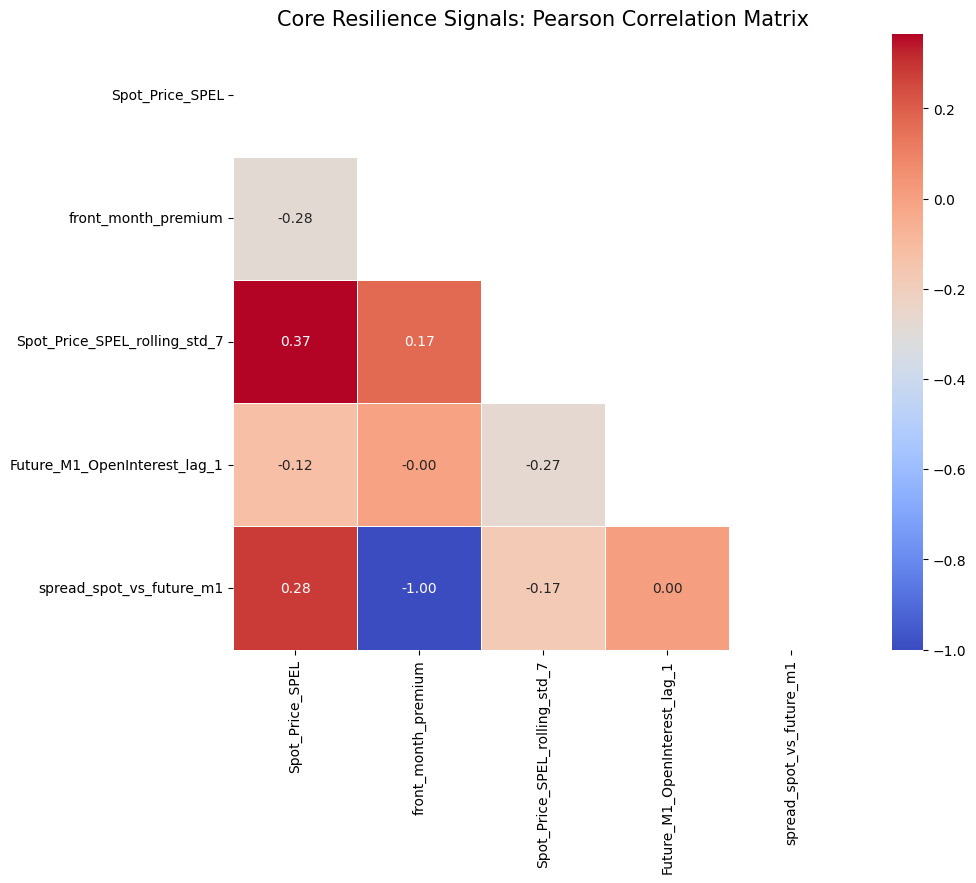

In [6]:
# Selecting a representative subset of features for the visual audit
core_signals = [
    SPOT_PRICE_COLUMN,
    'front_month_premium', # Calculated in build_future_features
    'Spot_Price_SPEL_rolling_std_7',
    'Spot_Price_SPEL_rolling_std_30',
    'Future_M1_OpenInterest_lag_1',
    'spread_spot_vs_future_m1'
]

# Ensure we only plot available columns
plot_cols = [c for c in core_signals if c in featured_df.columns]
corr = featured_df[plot_cols].corr()

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Core Resilience Signals: Pearson Correlation Matrix", fontsize=15)
plt.show()

## 5. Summary and Conclusions

The feature engineering process successfully generated 3 sets of indicators:
1.  **Expectation Indicators:** Spreads between Spot and Futures to guide **Financial Hedging**.
2.  **Risk Indicators:** Rolling standard deviations to guide **Operational Flexibility**.
3.  **Temporal Context:** Cyclical calendar features to handle the factory's weekend/holiday production constraints.

**Next Step:**
The resulting dataset will be merged with the **Weather Dataset** (`openmeteo_raw.csv`) in the next notebook. This will allow the model to correlate energy price volatility with renewable generation potential (Wind/Solar), completing the resilience state-space.